## Model Validation Notebook

**Objective :** To independently validate the PD model using:   
- Backtesting  (calibration check)
- Benchmarking (Challenger Model)  
- Sensitivity Analysis
  

In [1]:
import sys
import os
sys.path.append("..")

In [2]:
import numpy as np
import pandas as pd
import pickle
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from src.model_evaluation import ModelEvaluation

In [3]:
print(os.getcwd())

C:\Users\welcome\Credit risk project\pipeline


In [4]:


with open('../artifacts/pd_model.pkl','rb') as f:
    model=pickle.load(f)

with open('../artifacts/woe_binner.pkl', 'rb') as f:
    woe=pickle.load(f)

with open('../artifacts/final_features.pkl','rb') as f:
    features=pickle.load(f)

In [5]:
from src.data_preprocessing import LoanDataPreprocessor
from src.feature_engineering import apply_feature_engineering
from src.model_validation import backtesting
from src.model_validation import challenger_model
from src.model_validation import sensitivity_analysis
from src.model_validation import stress_simulation

In [6]:
data_processor=LoanDataPreprocessor()
df_oot=data_processor.preprocess('../data/loan_data_2015.csv')
df_oot_fe,feature_cols=apply_feature_engineering(df_oot, None)
df_oot_woe=woe.apply_bins(df_oot_fe)
df_oot_woe=woe.transform(df_oot_woe)

INFO:root:Preprocessing version: v1.0
INFO:root:Cleaning employment length
INFO:root:Cleaning term
INFO:root:dates conversion
INFO:root:credit age creation
INFO:root:missing values handling
INFO:root:target variable creation
INFO:root:Applying outlier capping on 47 columns
INFO:root:final dataset shape: (421094, 80)
INFO:root:Starting feature engineering
INFO:root:Applying categorical grouping
INFO:root:Feature engineering completed. Shape: (421094, 85)
INFO:root:Feature engineering version: v1.0


In [7]:
df_oot_woe.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,initial_list_status_woe,int_rate_bin_woe,dti_bin_woe,annual_inc_bin_woe,installment_bin_woe,delinq_2yrs_bin_woe,inq_last_6mths_bin_woe,credit_age_months_bin_woe,open_acc_bin_woe,total_acc_bin_woe
0,68444620,73334399,35000,35000,35000.0,60 months,11.99,778.38,C,C1,...,0.223494,0.385109,0.235439,0.428106,-0.068403,-0.000472,0.195875,0.216844,0.043296,0.090641
1,68547583,73437441,8650,8650,8650.0,36 months,5.32,260.50,A,A1,...,0.223494,1.052007,0.199861,0.278822,-0.002328,-0.000472,0.195875,0.018155,-0.003823,0.033141
2,67849662,72708407,4225,4225,4225.0,36 months,14.85,146.16,C,C5,...,0.223494,-0.060795,0.083862,-0.197276,0.086846,0.004014,0.195875,-0.213277,-0.005804,-0.188009
3,68506885,73396712,10000,10000,10000.0,60 months,11.99,222.40,C,C1,...,0.223494,0.385109,-0.203865,-0.197276,0.086846,-0.000472,-0.062870,0.131776,-0.005804,0.033141
4,68341763,72928789,20000,20000,20000.0,60 months,10.78,432.66,B,B4,...,0.223494,0.385109,0.199861,0.022372,-0.002328,-0.000472,0.195875,0.018155,-0.005804,-0.059072


In [8]:
print('good_bad' in df_oot.columns)
print('good_bad' in df_oot_fe.columns)
print('good_bad' in df_oot_woe.columns)

True
True
True


In [9]:
print(len(features))

9


In [10]:
missing=set(features)-set(df_oot_woe.columns)
extra=set(df_oot_woe.columns)-set(features)
print('Missing_features',missing)
print('Extra features:', extra)


Missing_features set()
Extra features: {'inq_last_6mths_bin', 'il_util', 'funded_amnt', 'int_rate', 'out_prncp_inv', 'mths_since_rcnt_il', 'addr_state_woe', 'total_acc_bin_woe', 'last_credit_pull_d', 'last_pymnt_d', 'addr_state_grp', 'home_ownership', 'open_acc_6m', 'annual_inc_bin', 'total_acc_bin', 'credit_age_months_bin', 'dti_joint', 'total_rec_int', 'mths_since_last_delinq', 'last_pymnt_amnt', 'open_il_6m', 'desc', 'out_prncp', 'credit_age_months', 'verification_status_joint', 'loan_amnt', 'collection_recovery_fee', 'home_ownership_grp', 'loan_status', 'emp_length', 'mths_since_last_record', 'addr_state', 'pymnt_plan', 'earliest_cr_line', 'delinq_2yrs', 'url', 'issue_d', 'tot_coll_amt', 'term_int', 'all_util', 'int_rate_bin', 'sub_grade', 'mths_since_last_record_missing', 'total_pymnt', 'dti_bin', 'total_rec_late_fee', 'installment_bin', 'next_pymnt_d', 'collections_12_mths_ex_med', 'open_acc_bin', 'total_rec_prncp', 'total_rev_hi_lim', 'verification_status', 'term', 'inq_last_6mt

In [11]:
X_oot=df_oot_woe[features]
y_oot=df_oot_woe['good_bad']

In [12]:
print(X_oot.columns)
print(X_oot.shape)
print(y_oot.shape)

Index(['grade_woe', 'inq_last_6mths_bin_woe', 'annual_inc_bin_woe',
       'purpose_woe', 'credit_age_months_bin_woe', 'dti_bin_woe',
       'initial_list_status_woe', 'home_ownership_woe',
       'verification_status_woe'],
      dtype='object')
(421094, 9)
(421094,)


In [13]:
y_pred=model.predict_proba(X_oot)

INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)


### Backtesing

In [14]:
bt_results=backtesting(df_oot_woe, y_oot, y_pred)
bt_results

C:\Users\welcome\Credit risk project\pipeline\..\src\model_validation.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary=df.groupby('decile').agg(


,decile,avg_pd,actual_rate,count
0,"(0.012899999999999998, 0.0313]",0.024731,0.002992,42118
1,"(0.0313, 0.0458]",0.038313,0.004418,42101
2,"(0.0458, 0.0599]",0.053008,0.007693,42116
3,"(0.0599, 0.0726]",0.066286,0.009311,42103
4,"(0.0726, 0.0858]",0.079150,0.012965,42112
5,"(0.0858, 0.101]",0.093239,0.015055,42113
6,"(0.101, 0.12]",0.110122,0.019502,42251
7,"(0.12, 0.144]",0.131288,0.026000,41961
8,"(0.144, 0.181]",0.160922,0.032548,42122
9,"(0.181, 0.52]",0.226477,0.055990,42097


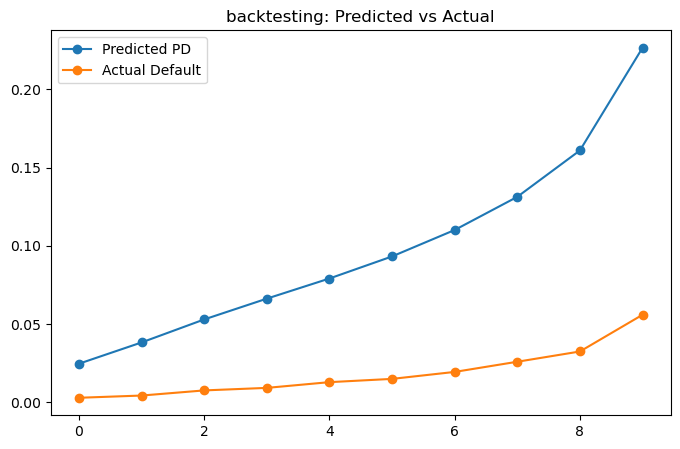

In [15]:
plt.figure(figsize=(8,5))
plt.plot(bt_results['avg_pd'], marker='o', label='Predicted PD')
plt.plot(bt_results['actual_rate'], marker='o', label='Actual Default')
plt.legend()
plt.title('backtesting: Predicted vs Actual')
plt.show()

In [16]:
from src.calibration import PDcalibrator

In [17]:
cal=PDcalibrator()

In [18]:
cal.load('../artifacts/calibration_model.pkl')

In [19]:
y_pred=model.predict_proba(X_oot)

INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)


In [20]:
y_pred_cal=cal.predict(y_pred)

In [21]:
bt_results_cal=backtesting(df_oot_woe, y_oot, y_pred_cal)
bt_results_cal

C:\Users\welcome\Credit risk project\pipeline\..\src\model_validation.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary=df.groupby('decile').agg(


,decile,avg_pd,actual_rate,count
0,"(0.00526, 0.00748]",0.007001,0.002992,42118
1,"(0.00748, 0.00868]",0.008052,0.004418,42101
2,"(0.00868, 0.01]",0.009365,0.007693,42116
3,"(0.01, 0.0114]",0.010732,0.009311,42103
4,"(0.0114, 0.0131]",0.012246,0.012965,42112
5,"(0.0131, 0.0153]",0.014149,0.015055,42113
6,"(0.0153, 0.0185]",0.016821,0.019502,42251
7,"(0.0185, 0.0237]",0.020886,0.026000,41961
8,"(0.0237, 0.0345]",0.028278,0.032548,42122
9,"(0.0345, 0.545]",0.058938,0.055990,42097


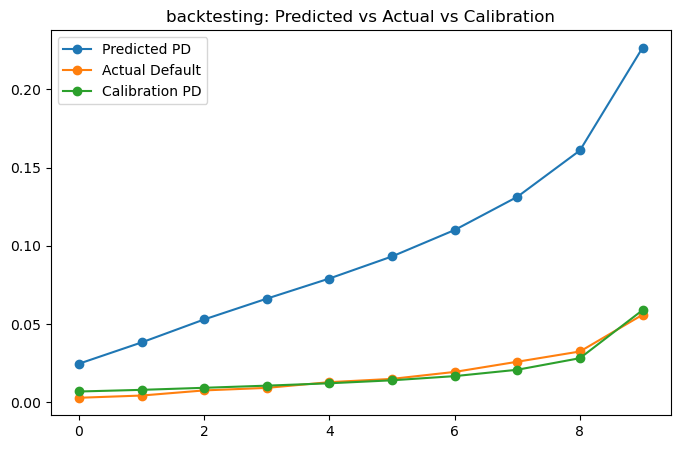

In [22]:
plt.figure(figsize=(8,5))
plt.plot(bt_results['avg_pd'], marker='o', label='Predicted PD')
plt.plot(bt_results['actual_rate'], marker='o', label='Actual Default')
plt.plot(bt_results_cal['avg_pd'], marker='o', label='Calibration PD')
plt.legend()
plt.title('backtesting: Predicted vs Actual vs Calibration')
plt.show()

In [23]:
from sklearn.metrics import brier_score_loss

In [24]:
brier_before=brier_score_loss(y_oot, y_pred)
brier_after_cal=brier_score_loss(y_oot, y_pred_cal)

In [25]:
print("Brier Before:", brier_before)
print("Brier After:", brier_after_cal)

Brier Before: 0.026358677844537853
Brier After: 0.018095280491157408


In [26]:
from sklearn.metrics import roc_auc_score

auc_oot = roc_auc_score(y_oot, y_pred)
auc_cal = roc_auc_score(y_oot, y_pred_cal)

print("AUC (Original):", auc_oot)
print("AUC (Calibrated):", auc_cal)

AUC (Original): 0.7216923463408826
AUC (Calibrated): 0.7216923463408826


In [29]:
eval_model=ModelEvaluation()

In [30]:
# ── OOT KS ───────────────────────────────────────────────────
ks_oot = eval_model.ks(y_oot, y_pred)
gini_oot = eval_model.gini(y_oot, y_pred)

print("=== OOT Validation Metrics ===")
print(f"OOT AUC  : {auc_oot:.4f}")
print(f"OOT Gini : {gini_oot:.4f}")
print(f"OOT KS   : {ks_oot:.4f}")

=== OOT Validation Metrics ===
OOT AUC  : 0.7217
OOT Gini : 0.4434
OOT KS   : 0.3282


## Challenger Model 

In [31]:
data_processor=LoanDataPreprocessor()
df_train=data_processor.preprocess('../data/loan_data_2007_2014.csv')
df_train_fe,feature_cols=apply_feature_engineering(df_train, None)
df_train_woe=woe.apply_bins(df_train_fe)
df_train_woe=woe.transform(df_train_woe)

INFO:root:Preprocessing version: v1.0
INFO:root:Cleaning employment length
INFO:root:Cleaning term
INFO:root:dates conversion
INFO:root:credit age creation
INFO:root:missing values handling
INFO:root:target variable creation
INFO:root:Applying outlier capping on 33 columns
INFO:root:final dataset shape: (466285, 81)
INFO:root:Starting feature engineering
INFO:root:Applying categorical grouping
INFO:root:Feature engineering completed. Shape: (466285, 86)
INFO:root:Feature engineering version: v1.0


In [32]:
X_train = df_train_woe[features]
y_train = df_train_woe['good_bad']

In [33]:
X_test=X_oot
y_test=y_oot

In [34]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(466285, 9)
(421094, 9)
(466285,)
(421094,)


In [35]:
rf_model, rf_preds,rf_auc=challenger_model('rf',X_train, y_train, X_oot, y_oot)

In [36]:
xgb_model, xgb_preds, xgb_auc=challenger_model('xgb', X_train, y_train, X_oot, y_oot)

C:\Users\welcome\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:14:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [37]:
lgb_model, lgb_preds, lgb_auc=challenger_model('lgb',X_train, y_train, X_oot, y_oot)

[LightGBM] [Info] Number of positive: 50968, number of negative: 415317
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.051848 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 59
[LightGBM] [Info] Number of data points in the train set: 466285, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.109307 -> initscore=-2.097844
[LightGBM] [Info] Start training from score -2.097844


In [38]:
print('Challenger rf AUC:', rf_auc, 'Challenger xgb AUC:',xgb_auc , 'Challenger lgb AUC:',lgb_auc)

Challenger rf AUC: 0.6206151747033065 Challenger xgb AUC: 0.7112694490650964 Challenger lgb AUC: 0.7181306520287122


In [39]:
ks_rf  = eval_model.ks(y_oot.values, rf_preds)
ks_xgb = eval_model.ks(y_oot.values, xgb_preds)
ks_lgb = eval_model.ks(y_oot.values, lgb_preds)

gini_rf  = eval_model.gini(y_oot.values, rf_preds)
gini_xgb = eval_model.gini(y_oot.values, xgb_preds)
gini_lgb = eval_model.gini(y_oot.values, lgb_preds)

print("\n=== Champion vs Challenger — OOT Metrics ===")
print(f"{'Model':<30} {'AUC':>7} {'Gini':>7} {'KS':>7} {'Regulatory'}")
print("-" * 70)
print(f"{'LR Champion':<30} {auc_oot:>7.4f} {gini_oot:>7.4f} {ks_oot:>7.4f}  ✅ Retained")
print(f"{'XGBoost Challenger':<30} {xgb_auc:>7.4f} {gini_xgb:>7.4f} {ks_xgb:>7.4f}  ⚠️ Rejected")
print(f"{'LightGBM Challenger':<30} {lgb_auc:>7.4f} {gini_lgb:>7.4f} {ks_lgb:>7.4f}  ⚠️ Rejected")
print(f"{'Random Forest Challenger':<30} {rf_auc:>7.4f} {gini_rf:>7.4f} {ks_rf:>7.4f}  ⚠️ Rejected")


=== Champion vs Challenger — OOT Metrics ===
Model                              AUC    Gini      KS Regulatory
----------------------------------------------------------------------
LR Champion                     0.7217  0.4434  0.3282  ✅ Retained
XGBoost Challenger              0.7113  0.4225  0.3122  ⚠️ Rejected
LightGBM Challenger             0.7181  0.4363  0.3204  ⚠️ Rejected
Random Forest Challenger        0.6206  0.2412  0.1857  ⚠️ Rejected


### Sensitivity Analysis

In [40]:
X=X_oot.copy()

In [41]:
X.head()

,grade_woe,inq_last_6mths_bin_woe,annual_inc_bin_woe,purpose_woe,credit_age_months_bin_woe,dti_bin_woe,initial_list_status_woe,home_ownership_woe,verification_status_woe
0,-0.056491,0.195875,0.428106,0.126488,0.216844,0.235439,0.223494,0.146051,0.053403
1,1.118678,0.195875,0.278822,0.274140,0.018155,0.199861,0.223494,0.146051,0.170388
2,-0.056491,0.195875,-0.197276,-0.043086,-0.213277,0.083862,0.223494,-0.165189,0.053403
3,-0.056491,-0.062870,-0.197276,-0.043086,0.131776,-0.203865,0.223494,-0.165189,0.170388
4,0.373511,0.195875,0.022372,0.126488,0.018155,0.199861,0.223494,0.146051,0.170388


In [42]:
coef=model.get_coefficients()
coef=coef.drop('const', errors='ignore')
top_vars = coef.abs().sort_values(ascending=False).head(4).index.tolist()

In [43]:
top_vars

['initial_list_status_woe',
 'grade_woe',
 'annual_inc_bin_woe',
 'inq_last_6mths_bin_woe']

In [44]:
coef

grade_woe                   -0.853806
inq_last_6mths_bin_woe      -0.578915
annual_inc_bin_woe          -0.739513
purpose_woe                 -0.485932
credit_age_months_bin_woe   -0.505443
dti_bin_woe                 -0.546035
initial_list_status_woe     -0.943361
home_ownership_woe          -0.505080
verification_status_woe     -0.506904
dtype: float64

In [45]:
features_to_test=top_vars

INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)


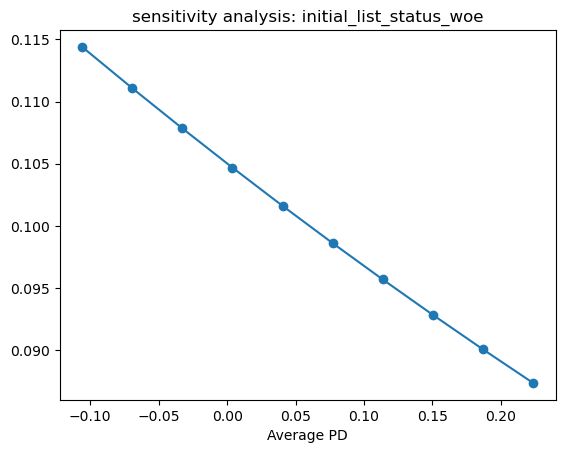

INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)


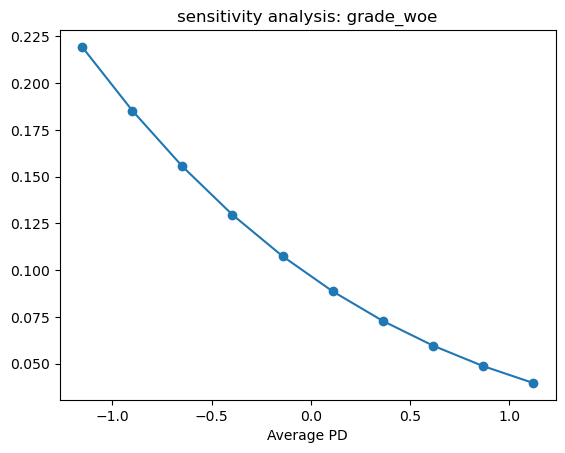

INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)


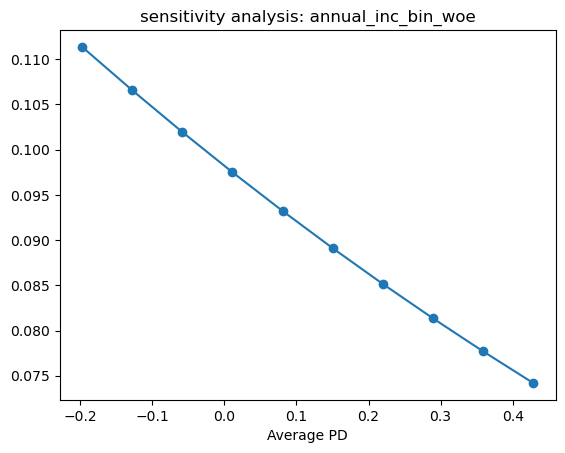

INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)
INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)


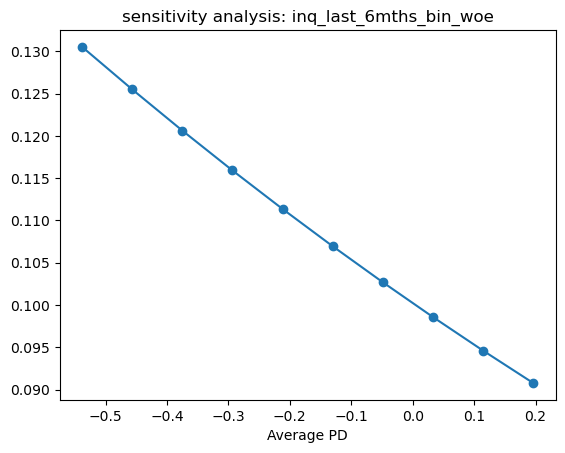

In [46]:
for feature in features_to_test:
    values, avg_pd=sensitivity_analysis(model, X, feature)

    plt.figure()
    plt.plot(values, avg_pd, marker='o')
    plt.title(f'sensitivity analysis: {feature}')
    plt.xlabel('Average PD')
    plt.show()

### Scenario-Based Stress Simulation

A simplified stress simulation was performed to evaluate model behavior under adverse borrower conditions.

Stress assumptions applied:

• Annual income reduced by 20%  
• Debt-to-Income ratio increased by 20%  
• Recent credit inquiries increased by 3  

These adjustments simulate deteriorating borrower conditions commonly associated with economic stress environments.

The stressed dataset was transformed using the same WoE mappings and evaluated using the final PD model.

In [47]:
from src.config import BIN_RULES

In [48]:
raw_stress_pd, cal_stress_pd = stress_simulation(
    df_oot_woe,
    model,
    cal,
    features
)

INFO:root:Generating predictions
INFO:root:scoring data shape : (421094, 10)


In [49]:
print("===== STRESS TEST RESULTS =====")

# Baseline calibrated PD
baseline_pd = y_pred_cal.mean()

# Stressed calibrated PD
stressed_pd = cal_stress_pd.mean()

print(f"Baseline Average PD : {baseline_pd:.4f}")
print(f"Stressed Average PD : {stressed_pd:.4f}")

# Relative increase
increase_pct = (
    (stressed_pd - baseline_pd)
    / baseline_pd
) * 100

print(f"PD Increase (%) : {increase_pct:.2f}%")

# Absolute increase
absolute_increase = stressed_pd - baseline_pd

print(f"Absolute PD Increase : {absolute_increase:.4f}")

===== STRESS TEST RESULTS =====
Baseline Average PD : 0.0186
Stressed Average PD : 0.0188
PD Increase (%) : 0.59%
Absolute PD Increase : 0.0001


Interpretation:

Under stressed borrower conditions, the portfolio-level predicted probability of default (PD) increased from 1.86% to 1.88%.

The moderate increase in PD indicates that the model responds directionally and consistently to deteriorating borrower characteristics, including reduced income, increased leverage, and elevated credit-seeking behavior.

The relatively controlled movement suggests that the scorecard demonstrates stable and robust behavior under moderate adverse conditions, without excessive sensitivity to small input perturbations.

This outcome indicates that the model maintains economically intuitive risk sensitivity while preserving portfolio-level stability under stressed borrower environments.

## Model Validation Report — Probability of Default (PD) Model

### 1. Objective

The objective of this validation is to independently assess the performance, stability, and reliability of the Probability of Default (PD) model developed using logistic regression with WoE-based feature transformation. The validation focuses on discriminatory power, calibration accuracy, and model robustness using out-of-time (OOT) data.


### 2. Model Overview

The PD model is developed using historical data (2007–2014) with Weight of Evidence (WoE) transformation and logistic regression. Feature selection was performed using Information Value (IV). The model outputs probability estimates of default for individual exposures.

### 3. Data Description
- Development Data : 2007-2014
- Validation Data : 2015 (OOT)

### 4. Validation Data

Validation was conducted on out-of-time (OOT) dataset from 2015 to assess model performance on unseen data and simulate real-world deployment conditions.



### 5. Performance Assessment

#### 5.1 Discriminatory Power

The model demonstrates strong discriminatory ability as evidenced by AUC and KS metrics (previously evaluated). Decile analysis confirms monotonic increase in default rates across risk buckets.

#### 5.2 Discriminatory Power (OOT Validation)

The model’s discriminatory performance was evaluated on out-of-time (OOT) data using AUC and Gini metrics.

* **AUC (Original Model):** 0.72169
* **AUC (Calibrated Model):** 0.72169
* **Gini Coefficient:** **2 × AUC − 1** : 0.4433

#### Interpretation:

* AUC measures the model’s ability to correctly rank defaulters vs non-defaulters.
* Gini coefficient is a linear transformation of AUC and is widely used in credit risk.

#### Observation:

* The AUC remains stable before and after calibration.
* This confirms that calibration did not impact the ranking ability of the model.

#### Conclusion:

The model demonstrates strong and stable discriminatory power, and calibration has preserved ranking performance while improving probability estimation.




### 6. Backtesting (Calibration Assessment)

Backtesting was performed by comparing predicted PDs against observed default rates across deciles.

#### 6.1 Observations (Pre-Calibration)

* Predicted PDs were consistently higher than actual default rates across all deciles.
* This indicates conservative bias in predicted probabilities
* The model shows strong ranking capability but poor calibration.

#### 6.2 Conclusion (Pre-Calibration)

The model exhibits a **calibration issue**, as predicted probabilities are not well aligned with observed outcomes despite good discriminatory performance.



### 7. Calibration Adjustment

A logistic recalibration approach was applied using predicted PD as input to align model outputs with observed default behavior.

#### 7.1 Post-Calibration Observations

* Significant reduction in the gap between predicted and actual default rates.
* Improved alignment across most deciles.
* Monotonicity and ranking performance preserved.

#### 7.2 Residual Observations

* Minor deviations remain in higher deciles, which are within acceptable tolerance limits.

#### 7.3 Quantitative Calibration Assessment (Brier Score)

To complement visual backtesting, the Brier Score was used to evaluate the accuracy of predicted probabilities.

* **Brier Score (Pre-Calibration):** 0.0263
* **Brier Score (Post-Calibration):** 0.0180
#### Interpretation:

* The Brier Score measures the mean squared difference between predicted probabilities and actual outcomes.
* A lower Brier Score indicates better probability estimation.

#### Observation:

* A reduction in Brier Score is observed after calibration.
* This confirms that calibration has improved the accuracy of predicted probabilities.

#### Conclusion:

The quantitative improvement in Brier Score supports the visual backtesting results, indicating enhanced calibration and better alignment of predicted PD with observed default rates.



### 8. Benchmarking 

Multiple challenger models including Random Forest, XGBoost, and LightGBM were developed to benchmark the performance of the logistic regression model.

Challenger models were trained on development data and evaluated on out-of-time (OOT) data to ensure fair comparison and avoid data leakage.


#### Results:

* Logistic Regression AUC: 0.673
* Random Forest AUC: 0.6206
* XGBoost AUC: 0.7112
* LightGBM AUC: 0.718
  
* Gradient boosting models (XGBoost and LightGBM) showed marginally higher predictive performance compared to logistic regression; however, the improvement was not considered sufficient to offset the reduced interpretability and governance transparency.

Logistic regression was retained due to:
- regulatory interpretability
- scorecard compatibility
- stable monotonic relationships
- ease of validation and monitoring


### 9. Sensitivity Analysis

Sensitivity analysis was conducted to evaluate the impact of key input variables on predicted probability of default.

The observed directional relationships are consistent with the WoE-transformed risk ordering established during model development.

#### Variables Tested:

Sensitivity analysis was performed on top model drivers identified based on coefficient magnitude:

* Sensitivity analysis was performed on the most influential WoE-transformed variables identified based on absolute logistic regression coefficient magnitude.

The primary variables tested include:

• initial_list_status_woe  
• grade_woe  
• annual_inc_bin_woe  
• inq_last_6mths_bin_woe

#### Observations:

* The model demonstrates smooth and monotonic relationships between selected variables and predicted PD.
* Changes in input variables result in consistent directional changes in predicted risk.
* No irregular or unstable behavior observed.
* Higher-risk WoE movements consistently resulted in elevated predicted PD values.
  

#### Conclusion:

The model exhibits stable and economically intuitive behavior across key drivers, confirming robustness of model response.


### 10. Stability Validation

#### 10.1 Temporal Stability

The model was evaluated on an out-of-time dataset (2015) to assess stability across time. The model maintained consistent discriminatory power, indicating robustness to temporal changes.

#### 10.2 Population Stability

Population Stability (PSI) analysis is handled in a separate monitoring pipeline and is not part of this validation scope.

#### Conclusion:

The model demonstrates strong temporal stability based on OOT validation, supporting its reliability under changing conditions.  
Population stability is assessed separately in the monitoring pipeline.

#### 11. Variable Justification

The final model variables were selected based on statistical significance, predictive power (Information Value), and business relevance.

Key considerations for variable inclusion:

* Variables demonstrate a strong and monotonic relationship with default risk after WoE transformation.
* Selected features show acceptable levels of multicollinearity.
* Each variable has clear economic intuition and relevance to borrower creditworthiness.

Examples:

• **Grade:** Lower credit grades indicate higher borrower risk.  
• **Debt-to-Income Ratio (DTI):** Higher DTI reflects increased repayment burden.  
• **Recent Credit Inquiries:** Frequent recent inquiries indicate elevated credit seeking behavior.  
• **Verification Status:** Differences in verification patterns capture varying borrower risk   characteristics.  

Conclusion:
The selected variables are both statistically robust and economically interpretable, supporting reliable credit risk assessment.

#### 12. Model Performance Interpretation

The model demonstrates moderate discriminatory power with an AUC of approximately 0.72 and a Gini coefficient of ~0.44.

Interpretation:

* The model is able to effectively rank-order borrowers based on default risk.
* Moderate AUC indicates acceptable separation between good and bad borrowers for retail credit portfolios.
* Stable performance across development and OOT datasets indicates robustness and limited overfitting.

Conclusion:
The model performance is consistent with industry expectations for retail credit risk models and is considered suitable for operational use.

#### 13. Business Interpretation

The scorecard translates statistical model outputs into actionable credit decisions, enabling risk-based segmentation and informed business strategies.

Higher scores correspond to lower probability of default, supporting intuitive interpretation for business users.

#### 14.Model Assumptions

* The relationship between predictors and probability of default is linear in the log-odds space, consistent with logistic regression assumptions.
* WoE transformation enforces a monotonic relationship between predictors and target variable.
* Training data is assumed to be representative of future portfolio behavior.
* Selected predictors are assumed to have no severe multicollinearity.
* Observations are assumed to be independent.
  
### 15. Model Governance Controls 

The model development and validation process incorporates governance-oriented controls including:

• Modular pipeline architecture  
• Independent train/test/OOT validation  
• WoE transformation traceability  
• Artifact versioning and model persistence  
• Monitoring support through PSI reporting  
• Separate validation and scoring pipelines  
• Documented model assumptions and limitations  
• Scenario-based sensitivity validation under adverse borrower conditions


#### 16. Model Limitations

- The model does not explicitly incorporate macroeconomic variables and may not fully capture economic downturn effects.
- Moderate discriminatory power with strong practical ranking capability (AUC ~0.72)
- Static model design does not adapt automatically to evolving borrower behavior.
- WoE binning may reduce granularity of information.
- Model is developed on observed performance data, which may introduce sample selection bias due to absence of rejected applicants.


#### 17. Model Use & Scope

The model is designed for retail credit risk assessment and supports multiple business functions.

Primary use cases include:

* Credit approval and rejection decisions
* Risk-based pricing and interest rate setting
* Credit limit assignment
* Portfolio risk monitoring and segmentation

Scope:

* Applicable to retail lending portfolios similar to the development dataset
* Intended for standard operating conditions
* Not designed for macroeconomic stress scenarios without additional adjustments

Conclusion:
The model is suitable for operational deployment within defined business scope and usage boundaries.

#### 18. Sensitivity & Scenario-Based Analysis

Scenario-based sensitivity analysis was performed by simulating adverse changes in borrower-level risk characteristics, including reduced annual income, increased debt-to-income ratio (DTI), and elevated recent credit inquiries.

Observations:

* Reduction in annual income resulted in higher predicted probability of default (PD).
* Increased borrower leverage and credit-seeking behavior contributed to elevated portfolio risk.
* Model response remained smooth and directionally consistent under stressed conditions.

Interpretation:

* The model reacts consistently to worsening borrower characteristics.
* No unstable or erratic prediction behavior was observed under simulated adverse scenarios.
* Portfolio-level PD increased moderately, indicating stable model sensitivity rather than excessive volatility.

Conclusion:

The model demonstrates appropriate directional sensitivity to adverse borrower scenarios while maintaining stable and economically intuitive behavior.

#### 19. Model Risk Assessment



| Risk Type        | Observation                                        | Impact     |
| ---------------- | -------------------------------------------------- | ---------- |
| Calibration Risk | Initial overestimation corrected via recalibration | Medium     |
| Data Drift       | Not evaluated in validation (covered in monitoring pipeline)                     | Medium (pending monitoring validation        |
| Model Bias       | Conservative bias present pre-calibration          | Acceptable |
|Implementation |Implementation controls were reviewed to ensure consistency between training and inference pipelines. | Medium |
|Behavioral Risk| Model shows consistent monotonic behavior|Low|

An implementation-related issue was identified during sensitivity analysis, where inconsistent handling of the intercept (constant term) caused instability in model predictions under specific input conditions.

The issue was addressed by enforcing explicit constant addition and ensuring alignment between training and inference feature structures. Post-remediation validation confirms stable and consistent model behavior.

#### 19.1 Validation Summary

The validation process confirmed that:

• The model maintains stable discriminatory power on out-of-time (OOT) data.

• Calibration adjustment improved probability estimation while preserving ranking performance.

• Challenger models provided limited performance improvement relative to logistic regression.

• Sensitivity analysis demonstrated stable and monotonic model behavior.

• Scenario-based stress testing confirmed directional risk sensitivity under adverse borrower conditions.

• Temporal stability was validated using 2015 OOT data.

• WoE transformation and scorecard structure remain interpretable and economically intuitive.

• No material instability or abnormal model behavior was identified during validation.

• Implementation consistency between training and inference pipelines was verified.

• The model is considered suitable for operational retail credit risk assessment within defined usage scope.


#### 20. Final Validation Conclusion

The PD model demonstrates strong discriminatory power and stable performance across time. Initial calibration issues were identified and successfully addressed through logistic recalibration.   
An implementation-related issue concerning intercept handling during sensitivity analysis was also identified and remediated, ensuring consistent and robust model inference.  
Post-calibration results indicate acceptable alignment between predicted and observed default rates.

#### 21. Validation Decision:

Overall, the model meets performance, stability, and calibration requirements expected for credit risk applications and is considered fit for intended use.


**Approved with calibration adjustment**

#### 22. Recommendations:

* Use calibrated PDs for production deployment
* Monitor calibration stability periodically
* Recalibrate or rebuild model if significant drift is observed
*  Periodically review variable stability and recalibration requirements under changing economic conditions

---
